In [1]:
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
from os import listdir
import tensorflow as tf
from os.path import join
from keras.layers import Dense
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from keras.models import Sequential
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.initializers import RandomUniform
from keras.layers import Conv2D, MaxPooling2D, Flatten

2024-02-21 10:16:19.433038: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-21 10:16:19.433173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-21 10:16:19.631099: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
!mkdir saved_models

In [3]:
DATA_PATH = "/kaggle/input/speech-commands-dataset"
SAVED_MODEL_PATH = join("/kaggle/working/saved_models","dnn_model.hdf5")
SELECTED_KEYWORDS = ["yes", "no"]
all_paths = []

yes_audios = listdir(join(DATA_PATH, "yes"))
no_audios = listdir(join(DATA_PATH, "no"))

for yes_audio in yes_audios:
    yes_path = join(join(DATA_PATH, "yes"), yes_audio)
    all_paths.append([yes_path, "yes"])

for no_audio in no_audios:
    no_path = join(join(DATA_PATH, "no"), no_audio)
    all_paths.append([no_path, "no"])
    
basic_data = pd.DataFrame(all_paths, columns=["Path", "Label"])

In [4]:
basic_data = shuffle(basic_data, random_state=33)
basic_data = basic_data.replace({"yes": 1, "no": 0})

/tmp/ipykernel_18/3558717243.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  basic_data = basic_data.replace({"yes": 1, "no": 0})


In [5]:
stat = basic_data["Label"].value_counts()
print(stat*100/stat.sum())

Label
1    50.644959
0    49.355041
Name: count, dtype: float64


In [6]:
X = basic_data["Path"]
y = basic_data["Label"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=45, stratify=y)

In [7]:
def read_and_pad_seq(X, max_length=8000):
    X_seq = np.empty((0, max_length), float)
    for index, file_path in tqdm(X.items(), total = X.shape[0]): 
        audio_segment, _ = librosa.load(file_path, sr=8000)
        k = audio_segment.shape[0]
        if k>=max_length:
            audio_segment = audio_segment[:max_length]
        elif k<max_length:
            audio_segment = np.pad(audio_segment,(0,max_length-k),'constant')
        X_seq = np.vstack((X_seq, audio_segment))
    return X_seq

In [8]:
X_train_seq = read_and_pad_seq(X_train)
X_test_seq = read_and_pad_seq(X_test)

100%|██████████| 2396/2396 [01:39<00:00, 24.07it/s]


In [9]:
def compute_spectrogram(raw_data):
    spectrum = librosa.feature.melspectrogram(y=raw_data, sr=8000, n_mels=64) 
    logmel_spectrum = librosa.power_to_db(S=spectrum, ref=np.max)
    return logmel_spectrum

def convert_to_spectrogram(X_seq):
    X_spectrogram = []
    for row in tqdm(X_seq):
        spectrum = compute_spectrogram(row) 
        X_spectrogram.append(spectrum)
    X_spectrogram = np.asarray(X_spectrogram)
    return X_spectrogram

X_train_spectrogram = convert_to_spectrogram(X_train_seq)
X_test_spectrogram = convert_to_spectrogram(X_test_seq)

100%|██████████| 2396/2396 [00:18<00:00, 127.92it/s]


In [10]:
class LossHistory(tf.keras.callbacks.Callback):
    def __init__(self,validation_data): 
        self.x_test = validation_data[0] 
        self.y_test= validation_data[1]
        
def on_train_begin(self, logs={}):
    self.history={'loss': [],'accuracy': [],'val_loss': [],'val_accuracy': [],'val_f1': []}
    
def on_epoch_end(self, epoch, logs={}):
    self.history['loss'].append(logs.get('loss')) 
    self.history['accuracy'].append(logs.get('accuracy'))
    
    if logs.get('val_loss', -1) != -1: 
        self.history['val_loss'].append(logs.get('val_loss'))
    if logs.get('val_accuracy', -1) != -1: 
        self.history['val_accuracy'].append(logs.get('val_accuracy'))
        
    y_pred= self.model.predict(self.x_test)
    y_label_pred = np.argmax(y_pred,axis=1) 
    y_test_arg = self.y_test
    F1 = f1_score(y_test_arg, y_label_pred, average='micro')
    self.history['val_f1'].append(F1)
    print(' Val F1 Score : ', np.round(F1,4))

In [11]:
UNITS = 25
LEARNING_RATE = 0.01 
NUM_CLASSES = 2
EPOCHS = 20 
BATCH_SIZE = 32
# IN_SHAPE = (8000,)
IN_SHAPE = (64, 16)
VALIDATION_SIZE = 0.25

In [12]:
adam_opt = tf.keras.optimizers.Adam(lr=LEARNING_RATE,
                                   beta_1=0.9,
                                   beta_2=0.999,
                                   epsilon=1e-8)

In [13]:
def myDNN(in_shape, adam_opt):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3),
              activation='relu',
              input_shape=(in_shape[0],
              in_shape[1], 1)))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (2, 2), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(Flatten())
    model.add(Dense(64, kernel_initializer=RandomUniform(minval=-0.05,
                    maxval=0.05), kernel_regularizer=l2(0.001),
                    activation='relu'))
    model.add(Dense(2, kernel_initializer=RandomUniform(minval=-0.05,
                    maxval=0.05), kernel_regularizer=l2(0.001),
                    activation='softmax'))
    model.compile(optimizer= adam_opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [14]:
dnn_model = myDNN(IN_SHAPE, adam_opt)

In [15]:
cp_callback = ModelCheckpoint(filepath=SAVED_MODEL_PATH,
                              monitor="val_accuracy",
                              verbose=1,
                              save_best_only=True,
                              mode="max")

In [16]:
history = dnn_model.fit(X_train_spectrogram,
                        y_train,
                        batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        validation_data=(X_test_spectrogram, y_test),
                        callbacks=[cp_callback])

Epoch 1/20
173/175 [============================>.] - ETA: 0s - loss: 0.3429 - accuracy: 0.8439
Epoch 1: val_accuracy improved from -inf to 0.90901, saving model to /kaggle/working/saved_models/dnn_model.hdf5
175/175 [==============================] - 5s 21ms/step - loss: 0.3422 - accuracy: 0.8440 - val_loss: 0.2437 - val_accuracy: 0.9090
Epoch 2/20
  7/175 [>.............................] - ETA: 3s - loss: 0.1809 - accuracy: 0.9286

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


172/175 [============================>.] - ETA: 0s - loss: 0.1361 - accuracy: 0.9511
Epoch 2: val_accuracy improved from 0.90901 to 0.95284, saving model to /kaggle/working/saved_models/dnn_model.hdf5
175/175 [==============================] - 3s 19ms/step - loss: 0.1369 - accuracy: 0.9508 - val_loss: 0.1370 - val_accuracy: 0.9528
Epoch 3/20
173/175 [============================>.] - ETA: 0s - loss: 0.1102 - accuracy: 0.9592
Epoch 3: val_accuracy improved from 0.95284 to 0.95701, saving model to /kaggle/working/saved_models/dnn_model.hdf5
175/175 [==============================] - 3s 19ms/step - loss: 0.1109 - accuracy: 0.9587 - val_loss: 0.1173 - val_accuracy: 0.9570
Epoch 4/20
175/175 [==============================] - ETA: 0s - loss: 0.0888 - accuracy: 0.9669
Epoch 4: val_accuracy improved from 0.95701 to 0.95910, saving model to /kaggle/working/saved_models/dnn_model.hdf5
175/175 [==============================] - 3s 19ms/step - loss: 0.0888 - accuracy: 0.9669 - val_loss: 0.1166 - 

In [17]:
def qualityLinePlot(history, labelsize=12, width=5):
    plt.rc("font", family="serif")
    plt.rc("xtick", labelsize=labelsize)
    plt.rc("ytick", labelsize=labelsize)
    plt.rc("axes", labelsize=labelsize)

    height = width / 1.618
    fig1, ax1 = plt.subplots()
    fig1.subplots_adjust(left=0.16, bottom=0.2, right=0.99, top=0.90)
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(["Training", "Validation"], loc="upper right")
    plt.show()

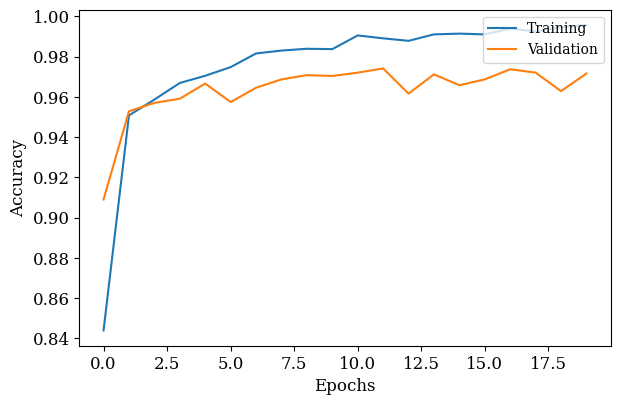

In [18]:
qualityLinePlot(history)